In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

In [7]:
def format_ticks(y, _):
        # Format with 2 decimals
        s = f'{y:.3f}'
        # Remove trailing zeros and dot if needed
        if '.' in s:
            s = s.rstrip('0').rstrip('.')
        # Remove leading zero before decimal point
        if s.startswith('0.') or s.startswith('-0.'):
            s = s.replace('0.', '.')
        return s

In [4]:
#var_df = pd.read_csv("../../results/random_gt_variation_lasso_results.csv")
#type_col = ["approx"] + ["gt"]*9
#var_df["type"] = type_col*30
#print(var_df)

     tissue  num_non_tfs  num_tfs       mae    f1_005    f1_001  \
0   Bladder            1       -1  0.016114  0.896320  0.675064   
1   Bladder            2       -1  0.015180  0.899763  0.720340   
2   Bladder            3       -1  0.015034  0.901092  0.723766   
3   Bladder            4       -1  0.014790  0.898535  0.736753   
4   Bladder            5       -1  0.014889  0.899495  0.743187   
..      ...          ...      ...       ...       ...       ...   
90   Uterus           60       -1  0.013564  0.906463  0.835516   
91   Uterus           70       -1  0.013600  0.907168  0.837468   
92   Uterus           80       -1  0.013529  0.908017  0.840132   
93   Uterus           90       -1  0.013551  0.907663  0.837238   
94   Uterus          100       -1  0.013543  0.909451  0.836964   

    abs_time_saving  rel_time_saving  abs_emission_saving  \
0        943.100768       224.596085           139.868560   
1        943.242291       232.393591           139.862495   
2        943

/tmp/ipykernel_8425/220021449.py:74: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = total_time_df.applymap(lambda x: f"{x:.1f}" if pd.notnull(x) else "")


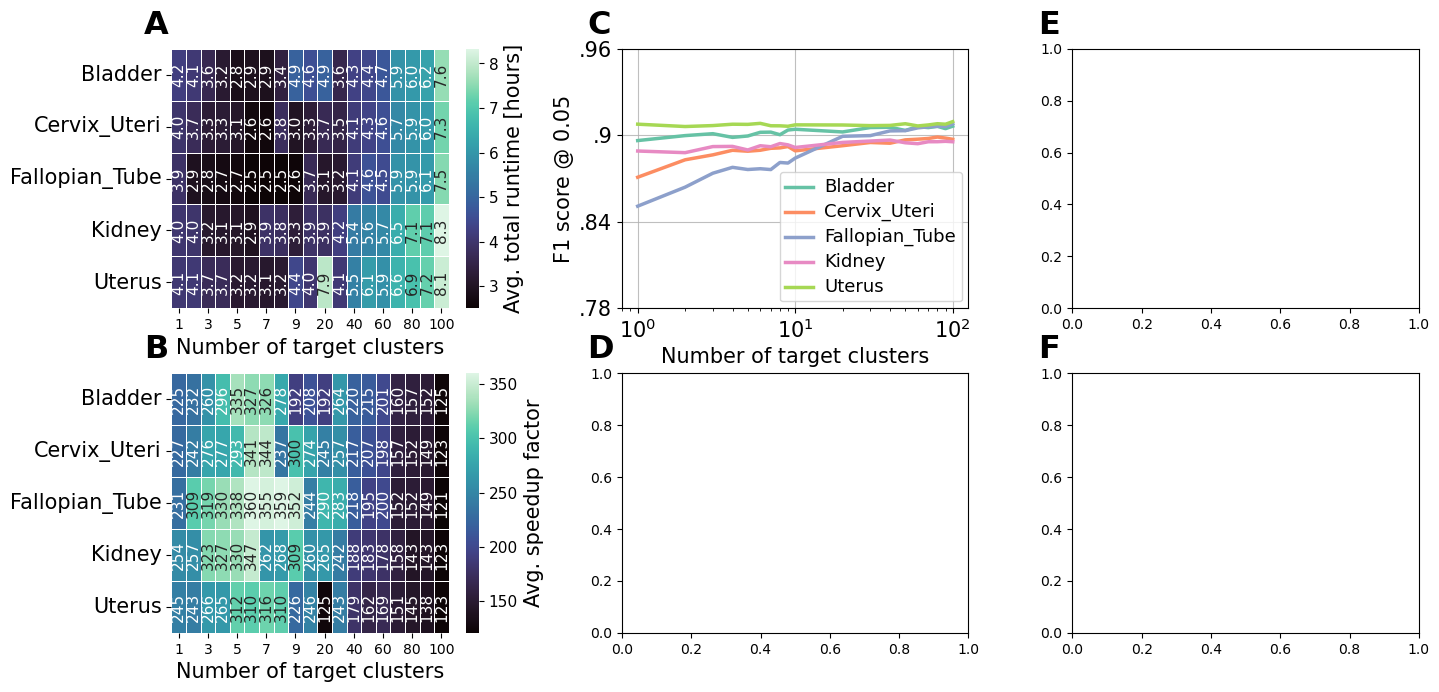

In [9]:
def plot_random_target_results(results_path : str, bh_path : str, var_df : pd.DataFrame):
    
    # Load results df.
    results_df = pd.read_csv(results_path)
    results_df['total_runtime'] = results_df['total_runtime']/3600.0
    results_df['abs_time_saving'] = results_df['abs_time_saving']/3600.0
    print(results_df)
    # Load BH-corrected results.
    bh_df = pd.read_csv(bh_path)
    bh_df = bh_df[bh_df['f1_005']!=0.0]

    
    # Create one large mosaic plot.
    fig, axs = plt.subplot_mosaic([['A', 'C', 'E'], ['B', 'D', 'F']])
    fig.set_size_inches(14.5, 7)
    axs_list = list(axs.values())
    label_fontsize = 15
    
    # Draw regression lines per bin
    line1 = sns.lineplot(
    data=results_df,
    x='num_non_tfs',
    y='f1_005',
    hue='tissue',
    ax=axs['C'],
    palette=sns.color_palette("Set2", 5)  ,
    linewidth=2.5
    #errorbar='sd',
    #err_style='bars'
    )
    line1.legend(title='')
    axs['C'].set_xlabel('Number of target clusters', fontsize=label_fontsize)
    axs['C'].set_ylabel('F1 score @ 0.05', fontsize=label_fontsize)
    axs['C'].set_yticks([0.78, 0.84, 0.9, 0.96])
    axs['C'].tick_params(axis='x', labelsize=label_fontsize)
    axs['C'].tick_params(axis='y', labelsize=label_fontsize)
    formatter = FuncFormatter(format_ticks)
    axs['C'].yaxis.set_major_formatter(formatter)
    axs['C'].grid(True, alpha=0.8)
    axs['C'].set_xscale('log')
    sns.move_legend(axs['C'], "lower right")#, bbox_to_anchor=(1.3, -0.38))
    plt.setp(axs['C'].get_legend().get_texts(), fontsize=label_fontsize-2)
    plt.setp(axs['C'].get_legend().get_title(), fontsize=label_fontsize-2)
    
    # Draw regression lines per bin
    #line1 = sns.lineplot(
    #data=bh_df,
    #x='num_non_tfs',
    #y='f1_005',
    #hue='tissue',
    #ax=axs['D'],
    #palette=sns.color_palette("Set2", 5)  ,
    #linewidth=2.5,
    #legend=False
    #errorbar='sd',
    #err_style='bars'
    #)
    #line1.legend(title='')
    #axs['D'].set_xlabel('Number of target clusters', fontsize=label_fontsize)
    #axs['D'].set_ylabel('F1 score @ 0.05', fontsize=label_fontsize)
    #axs['D'].set_yticks([0.78, 0.84, 0.9, 0.96])
    #axs['D'].tick_params(axis='x', labelsize=label_fontsize)
    #axs['D'].tick_params(axis='y', labelsize=label_fontsize)
    #formatter = FuncFormatter(format_ticks)
    #axs['D'].yaxis.set_major_formatter(formatter)
    #axs['D'].grid(True, alpha=0.8)
    #axs['D'].set_xscale('log')

    # --- Pivot to wide format for heatmap ---
    total_time_df = results_df.pivot(index='tissue', columns='num_non_tfs', values='total_runtime')
    total_time_df = total_time_df.sort_index().sort_index(axis=1)

    # --- Annotate heatmap with formatted labels ---
    annot_labels = total_time_df.applymap(lambda x: f"{x:.1f}" if pd.notnull(x) else "")

    # --- Plot first heatmap: total runtime ---
    heat1 = sns.heatmap(
        total_time_df,
        cmap="mako",
        linewidths=0.5,
        linecolor='white',
        annot=annot_labels,
        annot_kws={
        "size": label_fontsize - 4,
        "rotation": 90,     # 🔹 rotate text inside cells (degrees)
        "ha": "center",     # horizontal alignment (e.g., 'center', 'left', 'right')
        "va": "center"      # vertical alignment (e.g., 'center', 'top', 'bottom')
    },
    fmt='',
    cbar_kws={'label': 'Avg. total runtime [hours]'},
    ax=axs['A']
    )

    # --- Format colorbar and axes ---
    cbar = heat1.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(label_fontsize)
    cbar.ax.tick_params(labelsize=label_fontsize - 4)

    axs['A'].set_xlabel('Number of target clusters', fontsize=label_fontsize)
    axs['A'].set_ylabel('', fontsize=label_fontsize)
    axs['A'].tick_params(axis='x', labelsize=label_fontsize-5)
    axs['A'].tick_params(axis='y', labelsize=label_fontsize)

    # --- Pivot for second heatmap ---
    speedup_wide = results_df.pivot(index='tissue', columns='num_non_tfs', values='rel_time_saving')
    speedup_wide = speedup_wide.sort_index().sort_index(axis=1)

    # --- Plot second heatmap: speedup ---
    heat2 = sns.heatmap(
    speedup_wide,
    cmap="mako",
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt=".0f",
    cbar_kws={'label': r'Avg. speedup factor'},
    ax=axs['B'],
    annot_kws={
        "size": label_fontsize-4,
        "rotation": 90,     # 🔹 rotate text inside cells (degrees)
        "ha": "center",     # horizontal alignment (e.g., 'center', 'left', 'right')
        "va": "center"      # vertical alignment (e.g., 'center', 'top', 'bottom')
    }
)

    cbar = heat2.collections[0].colorbar
    #cbar.set_ticks([130, 230, 330])
    cbar.ax.yaxis.label.set_size(label_fontsize)
    cbar.ax.tick_params(labelsize=label_fontsize - 4)

    axs['B'].set_xlabel('Number of target clusters', fontsize=label_fontsize)
    axs['B'].set_ylabel('', fontsize=label_fontsize)
    axs['B'].tick_params(axis='x', labelsize=label_fontsize-5)
    axs['B'].tick_params(axis='y', labelsize=label_fontsize)
    #axs['B'].set_aspect(aspect=2.3)
    
    
    labels = {'A': 'A', 'B': 'B', 'C': 'C', 'D': 'D', 'E':'E', 'F': 'F'}

    for key, label in labels.items():
        ax = axs[key]
        ax.text(
            -0.1, 1.15, label,  # x, y (in axes fraction coords)
            transform=ax.transAxes,
            fontsize=23,
            fontweight='bold',
            va='top',
            ha='left'
        )
    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.25, wspace=0.3)
    #plt.show()
    plt.savefig("approximation_results_ridge.pdf", format='pdf', bbox_inches='tight')
    
results_path = "../../results/random_targets_ridge_no_bh_results.csv"
bh_path = "../../results/random_targets_ridge_with_bh_results.csv"
var_df = pd.DataFrame()
plot_random_target_results(results_path, bh_path, var_df)